# Unidad 3 – House Prices: Clustering con y sin PCA
**Machine Learning – Escuela de Ingeniería, Universidad Mayor**

---

Este cuaderno aplica los contenidos de la **Unidad 3** sobre la base de datos *House Prices*.  
Se abordan los cuatro puntos solicitados:

| # | Punto |
|---|-------|
| 1 | Preparación de datos (limpieza, OHE, normalización) |
| 2 | Experimento con y sin PCA |
| 3 | Challenge entre algoritmos (distancia vs densidad) |
| 4 | Evaluación con métricas y análisis de diferenciación |
| 5 | Carga a GitHub |

> **Variable objetivo de referencia:** `SalePrice` → binarizada como `HighPrice` (1 = sobre la mediana)

## 0. Instalación de dependencias

In [ ]:
!pip install kneed -q

## 1. Carga del dataset

Se carga el archivo `train.csv` de House Prices desde Google Colab.  
Si trabajas en entorno local, reemplaza el bloque de carga por `pd.read_csv('train.csv')`.

In [ ]:
from google.colab import files as colab_files
uploaded = colab_files.upload()

Saving train.csv to train.csv


In [ ]:
import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print(f'Archivo cargado: {file_name}')
print(f'Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas')
display(df.head())

Archivo cargado: train.csv
Dimensiones: 1460 filas × 81 columnas


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


---
## 📌 Punto 1 – Preparación de datos

### 1a. Limpieza de datos

**Justificación:**  
El dataset House Prices presenta columnas con alto porcentaje de valores nulos que no aportan información útil
(p. ej. `PoolQC`, `MiscFeature`, `Alley` superan el 80% de nulos).  
Eliminar estas columnas evita que la imputación introduzca sesgos artificiales.  
Además, la columna `Id` es un identificador sin valor predictivo y debe descartarse.

In [ ]:
# ── 1a. Limpieza ──────────────────────────────────────────────────────────

# Eliminar columna Id (identificador sin valor predictivo)
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])
    print('Columna Id eliminada.')

# Calcular porcentaje de nulos por columna
missing_pct = df.isnull().mean().sort_values(ascending=False)
missing_high = missing_pct[missing_pct > 0.80]

print(f'\nColumnas con >80% nulos ({len(missing_high)}):')
print(missing_high.to_string())

# Eliminar columnas con más del 80% de nulos
df = df.drop(columns=missing_high.index.tolist())
print(f'\nDataset después de limpieza: {df.shape}')

Columna Id eliminada.

Columnas con >80% nulos (4):
PoolQC         0.995205
MiscFeature    0.963014
Alley          0.937671
Fence          0.807534

Dataset después de limpieza: (1460, 76)


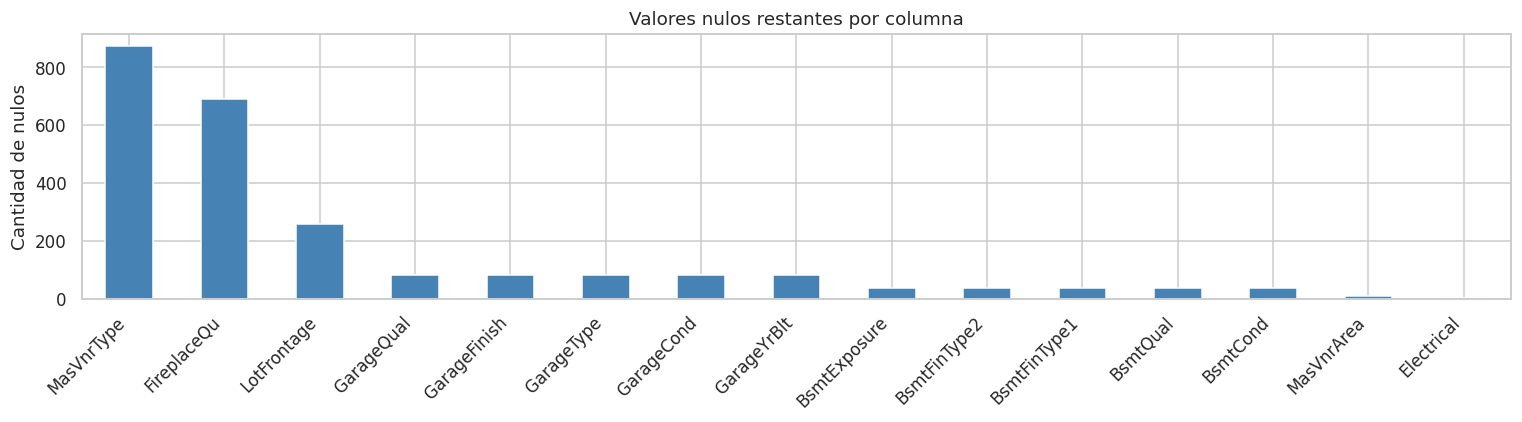

Columnas con valores nulos: 15


In [ ]:
# Visualizar distribución de valores nulos restantes
missing_rem = df.isnull().sum().sort_values(ascending=False)
missing_rem = missing_rem[missing_rem > 0]

plt.figure(figsize=(14, 4))
missing_rem.plot(kind='bar', color='steelblue')
plt.title('Valores nulos restantes por columna')
plt.ylabel('Cantidad de nulos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f'Columnas con valores nulos: {len(missing_rem)}')

### Variable de referencia `HighPrice`

Se binariza `SalePrice` sobre su mediana para poder evaluar (en el Punto 4)
si el clustering logra diferenciar viviendas de precio alto y bajo.  
Esta variable **no entra al modelo de clustering**; solo se usa como etiqueta de validación externa.

In [ ]:
# Crear variable de referencia antes de eliminar SalePrice del conjunto de features
umbral = df['SalePrice'].median()
df['HighPrice'] = (df['SalePrice'] > umbral).astype(int)

print(f'Mediana de SalePrice: ${umbral:,.0f}')
print('\nDistribución HighPrice:')
print(df['HighPrice'].value_counts().rename({0: 'Precio bajo (0)', 1: 'Precio alto (1)'}))

# Separar X e y
X_raw = df.drop(columns=['SalePrice', 'HighPrice'])
y_ref  = df['HighPrice']

Mediana de SalePrice: $163,000

Distribución HighPrice:
HighPrice
Precio bajo (0)    732
Precio alto (1)    728
Name: count, dtype: int64


### 1b. One Hot Encoding (OHE)

**Justificación:**  
Los algoritmos de clustering operan sobre distancias numéricas (euclídea, etc.).  
Las variables categóricas en texto (p. ej. `Neighborhood`, `MSZoning`, `HouseStyle`) no tienen
un orden natural, por lo que se codifican con One Hot Encoding para evitar que el modelo interprete
falsos órdenes ordinales.  
Se usa `handle_unknown='ignore'` para robustecer el pipeline frente a categorías no vistas.

### 1c. Normalización

**Justificación:**  
El clustering basado en distancias (KMeans, Agglomerative, Birch) es sensible a la escala de las variables.
Una variable como `GrLivArea` (metros cuadrados) tiene rangos de cientos, mientras que
`FullBath` varía entre 0 y 3; sin escalar, la primera dominaría por completo el cálculo de distancias.  
Se elige `StandardScaler` (media=0, std=1) porque es compatible con PCA y con los algoritmos
de densidad (DBSCAN, OPTICS) que también son sensibles a la escala.  
Los valores nulos numéricos se imputan con la mediana (robusta a outliers).

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features     = X_raw.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_raw.select_dtypes(exclude=['number']).columns.tolist()

print(f'Variables numéricas:   {len(numeric_features)}')
print(f'Variables categóricas: {len(categorical_features)}')

# Pipeline numérico: imputación por mediana + estandarización
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Pipeline categórico: imputación por moda + OHE
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  ohe)
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_processed = preprocessor.fit_transform(X_raw)

print(f'\nDimensión original:     {X_raw.shape}')
print(f'Dimensión transformada: {X_processed.shape}')
print('\n✅ Datos preparados correctamente.')

Variables numéricas:   36
Variables categóricas: 39

Dimensión original:     (1460, 75)
Dimensión transformada: (1460, 274)

✅ Datos preparados correctamente.


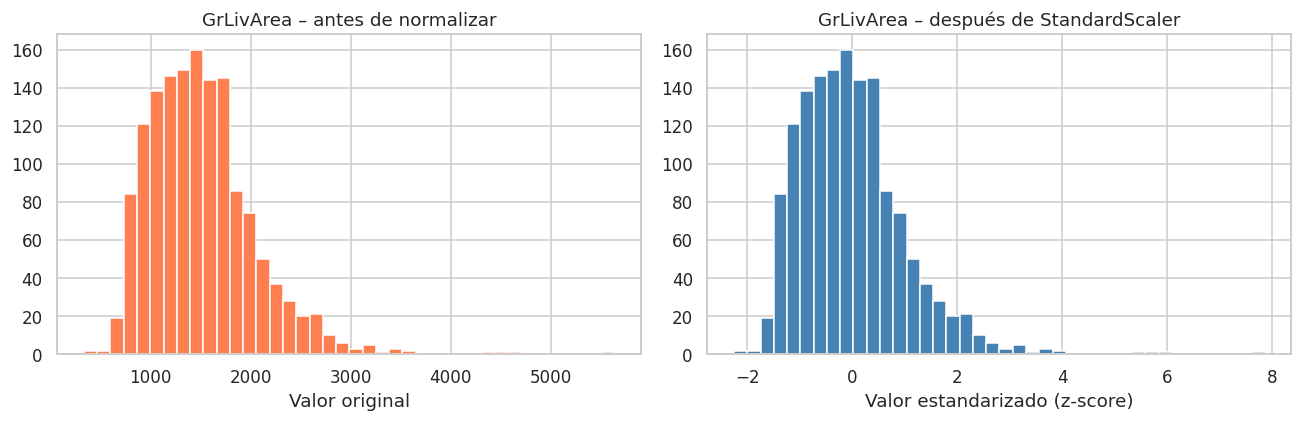

In [ ]:
# Visualizar distribución de algunas variables numéricas clave antes y después de normalizar
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(X_raw['GrLivArea'].dropna(), bins=40, color='coral', edgecolor='white')
axes[0].set_title('GrLivArea – antes de normalizar')
axes[0].set_xlabel('Valor original')

idx_grliv = numeric_features.index('GrLivArea')
axes[1].hist(X_processed[:, idx_grliv], bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('GrLivArea – después de StandardScaler')
axes[1].set_xlabel('Valor estandarizado (z-score)')

plt.tight_layout()
plt.show()

---
## 📌 Punto 2 – Experimento con y sin PCA

### 2b. Base de datos sin PCA

Se conserva la matriz transformada tal cual, con todas sus dimensiones.
Esto permite comparar el efecto de la reducción dimensional sobre la calidad del clustering.

In [ ]:
X_no_pca = X_processed.copy()
print(f'Base sin PCA: {X_no_pca.shape}')

Base sin PCA: (1460, 274)


### 2a. Base de datos con PCA

**Justificación del uso de PCA:**  
Con 200+ dimensiones tras el OHE, el espacio de alta dimensionalidad deteriora las distancias
euclídeas (maldición de la dimensionalidad), dificultando la formación de clusters compactos.  
PCA proyecta los datos a un subespacio ortogonal de menor dimensión, conservando la máxima varianza.

**Criterio de selección de componentes:**  
Se selecciona el número mínimo de componentes que acumulan al menos el **90% de la varianza explicada**.
Este umbral es un estándar ampliamente utilizado en la literatura porque balancea
reducción de ruido y retención de información relevante.

Componentes para explicar ≥90% de varianza: 50
Reducción dimensional: 274 → 50 componentes


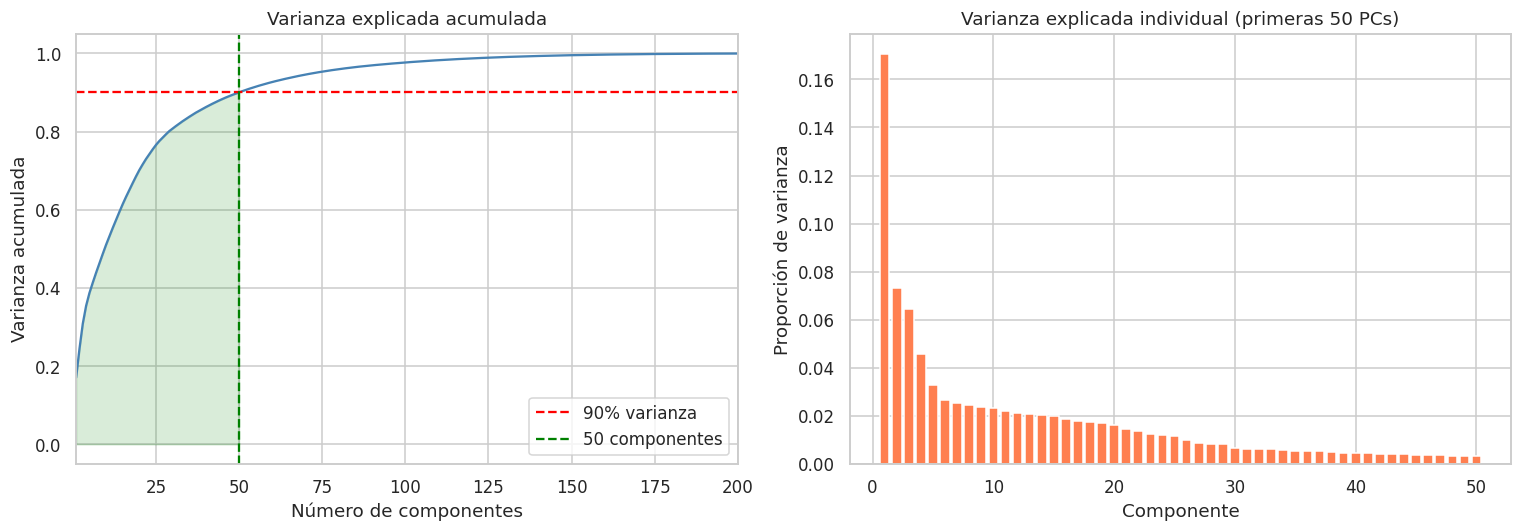

In [ ]:
from sklearn.decomposition import PCA

# Ajuste completo para analizar varianza acumulada
pca_full = PCA(random_state=42).fit(X_processed)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)
n_comp_90 = int(np.argmax(cum_var >= 0.90)) + 1

print(f'Componentes para explicar ≥90% de varianza: {n_comp_90}')
print(f'Reducción dimensional: {X_processed.shape[1]} → {n_comp_90} componentes')

# ── Gráfico de varianza acumulada ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Varianza acumulada
axes[0].plot(range(1, len(cum_var)+1), cum_var, color='steelblue', linewidth=1.5)
axes[0].axhline(0.90, color='red',   linestyle='--', label='90% varianza')
axes[0].axvline(n_comp_90, color='green', linestyle='--', label=f'{n_comp_90} componentes')
axes[0].fill_between(range(1, n_comp_90+1), cum_var[:n_comp_90], alpha=0.15, color='green')
axes[0].set_xlim([1, min(200, len(cum_var))])
axes[0].set_title('Varianza explicada acumulada')
axes[0].set_xlabel('Número de componentes')
axes[0].set_ylabel('Varianza acumulada')
axes[0].legend()

# Varianza individual (scree plot) – primeras 50 componentes
axes[1].bar(range(1, 51), pca_full.explained_variance_ratio_[:50], color='coral')
axes[1].set_title('Varianza explicada individual (primeras 50 PCs)')
axes[1].set_xlabel('Componente')
axes[1].set_ylabel('Proporción de varianza')

plt.tight_layout()
plt.show()

In [ ]:
# Aplicar PCA con el número óptimo de componentes
pca = PCA(n_components=n_comp_90, random_state=42)
X_pca = pca.fit_transform(X_processed)

print(f'Base con PCA: {X_pca.shape}')
print(f'Varianza total explicada: {pca.explained_variance_ratio_.sum():.4f}')

Base con PCA: (1460, 50)
Varianza total explicada: 0.9000


---
## 📌 Punto 3 – Challenge entre algoritmos (Benchmarking)

Se comparan **7 modelos** de clustering divididos en dos categorías:

| Categoría | Algoritmos |
|-----------|-----------|
| 📐 **Distancia** | KMeans (k=2), KMeans (k=3), Agglomerative (k=2), Agglomerative (k=3), Birch (k=2) |
| 🌀 **Densidad** | DBSCAN, OPTICS |

**Justificación de la elección:**
- **KMeans** es el algoritmo de clustering de distancia más ampliamente utilizado; se prueban k=2 y k=3 ya que tenemos una variable binaria de referencia.
- **AgglomerativeClustering** construye jerarquías bottom-up; es más robusto a outliers que KMeans.
- **Birch** es eficiente en grandes datasets y utiliza una estructura de árbol para resumir los datos.
- **DBSCAN** detecta clusters de forma arbitraria y es capaz de identificar ruido/outliers.
- **OPTICS** es una mejora de DBSCAN que no requiere un epsilon fijo, siendo más flexible.

### Tuning de DBSCAN con gráfico k-distancia

**Justificación:**  
El parámetro `eps` de DBSCAN define el radio de vecindad. Un valor demasiado pequeño genera todo como ruido;
uno demasiado grande une todos los puntos en un cluster.  
El método del **codo en la curva k-distancia** (distancia al k-ésimo vecino más cercano, con k = 2×dimensiones)
es el procedimiento estándar para seleccionar `eps` automáticamente.

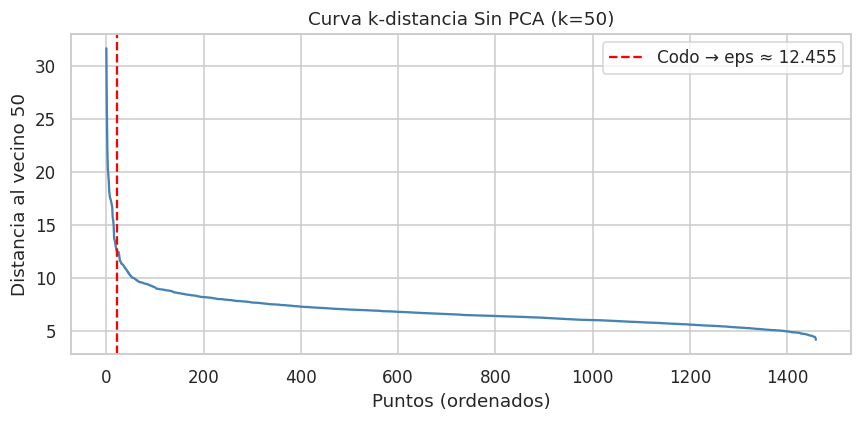

eps óptimo Sin PCA: 12.4554


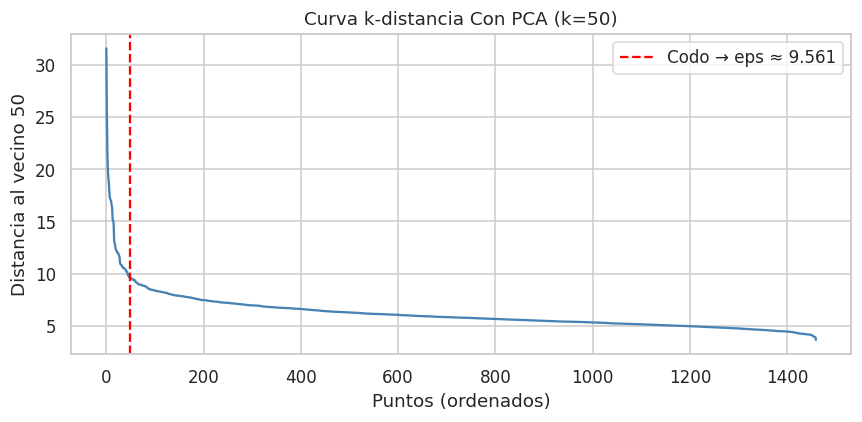

eps óptimo Con PCA: 9.5606


In [ ]:
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator

def tune_dbscan_eps(X_data, label=''):
    """Encuentra el eps óptimo para DBSCAN usando la curva k-distancia."""
    k = max(2, min(2 * X_data.shape[1], 50))  # k = 2*dims, cap en 50
    nbrs = NearestNeighbors(n_neighbors=k).fit(X_data)
    distances, _ = nbrs.kneighbors(X_data)
    k_dist = np.sort(distances[:, -1])[::-1]

    # Detectar codo automáticamente
    kneedle = KneeLocator(range(len(k_dist)), k_dist, S=1.0,
                          curve='convex', direction='decreasing')
    eps_opt = k_dist[kneedle.knee] if kneedle.knee else np.percentile(k_dist, 10)

    plt.figure(figsize=(8, 4))
    plt.plot(k_dist, color='steelblue', linewidth=1.5)
    if kneedle.knee:
        plt.axvline(kneedle.knee, color='red', linestyle='--',
                    label=f'Codo → eps ≈ {eps_opt:.3f}')
    plt.title(f'Curva k-distancia {label} (k={k})')
    plt.xlabel('Puntos (ordenados)')
    plt.ylabel(f'Distancia al vecino {k}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f'eps óptimo {label}: {eps_opt:.4f}')
    return eps_opt

eps_no_pca = tune_dbscan_eps(X_no_pca, label='Sin PCA')
eps_pca    = tune_dbscan_eps(X_pca,    label='Con PCA')

In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering, Birch, DBSCAN, OPTICS
from sklearn.metrics import (silhouette_score, calinski_harabasz_score,
                              davies_bouldin_score,
                              adjusted_rand_score, normalized_mutual_info_score)

def get_models(eps_val):
    """Retorna el diccionario de modelos con sus categorías."""
    return {
        # ── Distancia ──────────────────────────────────────────────
        'KMeans_k2':        ('Distancia', KMeans(n_clusters=2, random_state=42, n_init=10)),
        'KMeans_k3':        ('Distancia', KMeans(n_clusters=3, random_state=42, n_init=10)),
        'Agglomerative_k2': ('Distancia', AgglomerativeClustering(n_clusters=2)),
        'Agglomerative_k3': ('Distancia', AgglomerativeClustering(n_clusters=3)),
        'Birch_k2':         ('Distancia', Birch(n_clusters=2)),
        # ── Densidad ───────────────────────────────────────────────
        'DBSCAN':           ('Densidad',  DBSCAN(eps=eps_val, min_samples=10)),
        'OPTICS':           ('Densidad',  OPTICS(min_samples=10, xi=0.05)),
    }

def evaluate_model(X_data, labels, y_true, model_name, categoria, escenario):
    """Calcula métricas internas y externas para un clustering dado."""
    labels   = np.array(labels)
    y_true   = np.array(y_true)
    mask     = labels != -1
    n_clusters = len(set(labels[mask]))

    result = {
        'Escenario':           escenario,
        'Categoría':           categoria,
        'Modelo':              model_name,
        'Clusters_detectados': n_clusters,
        'Ruido_%':             round((~mask).mean() * 100, 1),
    }

    if n_clusters > 1:
        X_e, l_e, y_e = X_data[mask], labels[mask], y_true[mask]
        result['Silhouette']        = silhouette_score(X_e, l_e)
        result['Calinski_Harabasz'] = calinski_harabasz_score(X_e, l_e)
        result['Davies_Bouldin']    = davies_bouldin_score(X_e, l_e)
        result['ARI_HighPrice']     = adjusted_rand_score(y_e, l_e)
        result['NMI_HighPrice']     = normalized_mutual_info_score(y_e, l_e)
    else:
        for m in ['Silhouette','Calinski_Harabasz','Davies_Bouldin','ARI_HighPrice','NMI_HighPrice']:
            result[m] = np.nan

    return result

def run_benchmark(X_data, y_true, escenario, eps_val):
    results = []
    models  = get_models(eps_val)
    for name, (cat, model) in models.items():
        try:
            labels = model.fit_predict(X_data)
            results.append(evaluate_model(X_data, labels, y_true, name, cat, escenario))
        except Exception as e:
            results.append({'Escenario': escenario, 'Categoría': cat, 'Modelo': name,
                            'Error': str(e)})
    return pd.DataFrame(results)

print('Funciones de benchmarking definidas ✅')

Funciones de benchmarking definidas ✅


### 3a. Benchmark Sin PCA

In [ ]:
print('Ejecutando benchmark SIN PCA...')
results_no_pca = run_benchmark(X_no_pca, y_ref, 'Sin PCA', eps_no_pca)
display(results_no_pca.round(4))

Ejecutando benchmark SIN PCA...


,Escenario,Categoría,Modelo,Clusters_detectados,Ruido_%,Silhouette,Calinski_Harabasz,Davies_Bouldin,ARI_HighPrice,NMI_HighPrice
0,Sin PCA,Distancia,KMeans_k2,2,0.0,0.1296,207.5454,2.4987,0.5861,0.4900
1,Sin PCA,Distancia,KMeans_k3,3,0.0,0.1089,142.8966,2.6889,0.4726,0.4202
2,Sin PCA,Distancia,Agglomerative_k2,2,0.0,0.0948,152.7175,2.7799,0.2850,0.2399
3,Sin PCA,Distancia,Agglomerative_k3,3,0.0,0.0947,105.3574,3.8447,0.3406,0.2851
4,Sin PCA,Distancia,Birch_k2,2,0.0,0.0948,152.7175,2.7799,0.2850,0.2399
5,Sin PCA,Densidad,DBSCAN,1,0.8,NaN,NaN,NaN,NaN,NaN
6,Sin PCA,Densidad,OPTICS,5,96.0,0.3580,33.3383,1.0589,0.3427,0.5411


### 3b. Benchmark Con PCA

In [ ]:
print('Ejecutando benchmark CON PCA...')
results_pca = run_benchmark(X_pca, y_ref, 'Con PCA', eps_pca)
display(results_pca.round(4))

Ejecutando benchmark CON PCA...


,Escenario,Categoría,Modelo,Clusters_detectados,Ruido_%,Silhouette,Calinski_Harabasz,Davies_Bouldin,ARI_HighPrice,NMI_HighPrice
0,Con PCA,Distancia,KMeans_k2,2,0.0,0.1459,234.2499,2.3356,0.5861,0.4900
1,Con PCA,Distancia,KMeans_k3,3,0.0,0.1265,162.2113,2.5143,0.4710,0.4191
2,Con PCA,Distancia,Agglomerative_k2,2,0.0,0.1206,190.6252,2.4279,0.3514,0.3244
3,Con PCA,Distancia,Agglomerative_k3,3,0.0,0.0834,127.4567,3.5191,0.2879,0.2811
4,Con PCA,Distancia,Birch_k2,2,0.0,0.1206,190.6252,2.4279,0.3514,0.3244
5,Con PCA,Densidad,DBSCAN,1,1.1,NaN,NaN,NaN,NaN,NaN
6,Con PCA,Densidad,OPTICS,5,95.9,0.4595,37.6475,0.9422,0.1679,0.3708


### 3c. Tabla consolidada

In [ ]:
results_all = pd.concat([results_no_pca, results_pca], ignore_index=True)

# Ordenar por ARI (relación con variable real), luego Silhouette
results_sorted = results_all.sort_values(
    by=['ARI_HighPrice', 'NMI_HighPrice', 'Silhouette'],
    ascending=[False, False, False]
).reset_index(drop=True)

display(results_sorted.round(4))

,Escenario,Categoría,Modelo,Clusters_detectados,Ruido_%,Silhouette,Calinski_Harabasz,Davies_Bouldin,ARI_HighPrice,NMI_HighPrice
0,Con PCA,Distancia,KMeans_k2,2,0.0,0.1459,234.2499,2.3356,0.5861,0.4900
1,Sin PCA,Distancia,KMeans_k2,2,0.0,0.1296,207.5454,2.4987,0.5861,0.4900
2,Sin PCA,Distancia,KMeans_k3,3,0.0,0.1089,142.8966,2.6889,0.4726,0.4202
3,Con PCA,Distancia,KMeans_k3,3,0.0,0.1265,162.2113,2.5143,0.4710,0.4191
4,Con PCA,Distancia,Agglomerative_k2,2,0.0,0.1206,190.6252,2.4279,0.3514,0.3244
5,Con PCA,Distancia,Birch_k2,2,0.0,0.1206,190.6252,2.4279,0.3514,0.3244
6,Sin PCA,Densidad,OPTICS,5,96.0,0.3580,33.3383,1.0589,0.3427,0.5411
7,Sin PCA,Distancia,Agglomerative_k3,3,0.0,0.0947,105.3574,3.8447,0.3406,0.2851
8,Con PCA,Distancia,Agglomerative_k3,3,0.0,0.0834,127.4567,3.5191,0.2879,0.2811
9,Sin PCA,Distancia,Agglomerative_k2,2,0.0,0.0948,152.7175,2.7799,0.2850,0.2399


---
## 📌 Punto 4 – Evaluación con métricas

### 4a. Visualización comparativa de métricas

**Descripción de las métricas utilizadas:**

| Métrica | Tipo | Interpretación | Mejor valor |
|---------|------|----------------|-------------|
| **Silhouette** | Interna | Cohesión y separación de clusters | Máximo (cercano a 1) |
| **Calinski-Harabasz** | Interna | Relación entre dispersión inter e intra cluster | Máximo |
| **Davies-Bouldin** | Interna | Similitud promedio entre clusters | Mínimo |
| **ARI** | Externa | Concordancia con etiqueta real (`HighPrice`) | Máximo (cercano a 1) |
| **NMI** | Externa | Información mutua con etiqueta real | Máximo (cercano a 1) |

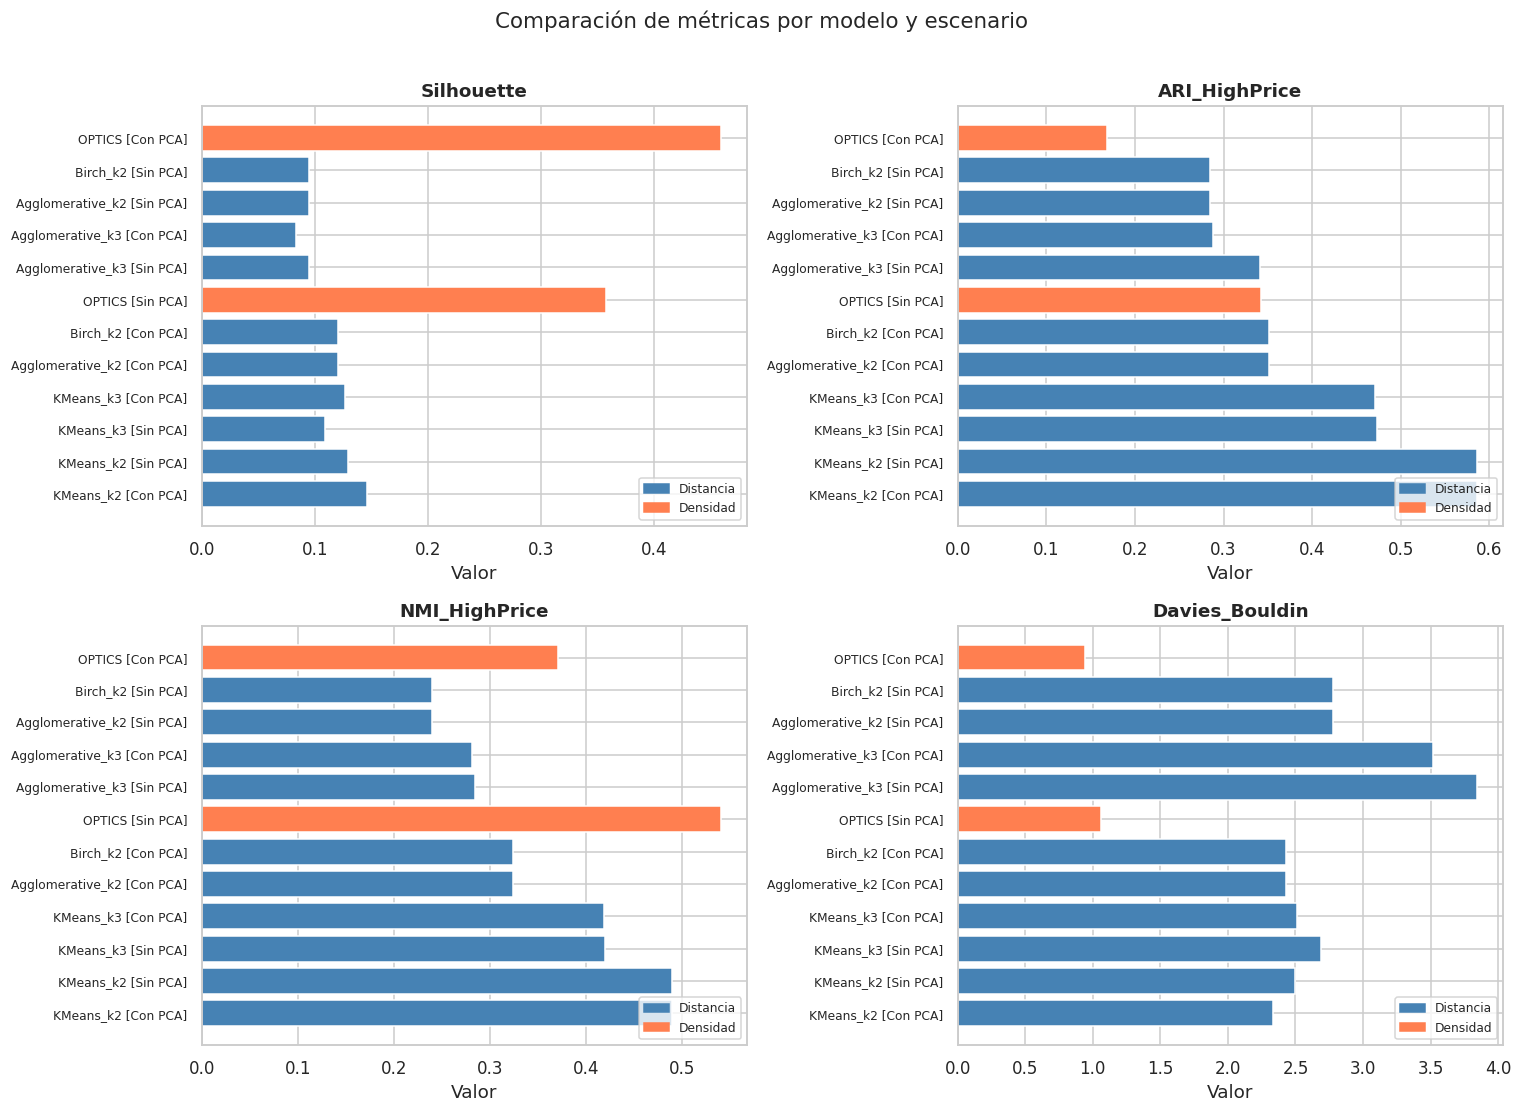

In [ ]:
metrics = ['Silhouette', 'ARI_HighPrice', 'NMI_HighPrice', 'Davies_Bouldin']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, metric in zip(axes.flatten(), metrics):
    data = results_sorted.dropna(subset=[metric]).copy()
    colors = data['Categoría'].map({'Distancia': 'steelblue', 'Densidad': 'coral'})
    bars = ax.barh(data['Modelo'] + ' [' + data['Escenario'] + ']',
                   data[metric], color=colors)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.tick_params(axis='y', labelsize=8)
    # Leyenda categoría
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='steelblue', label='Distancia'),
                        Patch(color='coral',     label='Densidad')],
              loc='lower right', fontsize=8)

plt.suptitle('Comparación de métricas por modelo y escenario', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 4b. Selección del mejor modelo

**Criterio de selección:**  
Se prioriza el **ARI (Adjusted Rand Index)** porque mide directamente qué tan bien los clusters
corresponden a la variable real `HighPrice`, corrigiendo por el azar.  
En caso de empate, se usa el **NMI (Normalized Mutual Information)** y luego el **Silhouette**.

In [ ]:
# Mejor fila
best_row = results_sorted.dropna(subset=['ARI_HighPrice']).iloc[0]

print('=' * 55)
print('  🏆 MEJOR MODELO SELECCIONADO')
print('=' * 55)
print(f"  Modelo:    {best_row['Modelo']}")
print(f"  Escenario: {best_row['Escenario']}")
print(f"  Categoría: {best_row['Categoría']}")
print('-' * 55)
print(f"  Silhouette:        {best_row.get('Silhouette', np.nan):.4f}")
print(f"  Calinski-Harabasz: {best_row.get('Calinski_Harabasz', np.nan):.2f}")
print(f"  Davies-Bouldin:    {best_row.get('Davies_Bouldin', np.nan):.4f}")
print(f"  ARI vs HighPrice:  {best_row.get('ARI_HighPrice', np.nan):.4f}")
print(f"  NMI vs HighPrice:  {best_row.get('NMI_HighPrice', np.nan):.4f}")
print('=' * 55)

  🏆 MEJOR MODELO SELECCIONADO
  Modelo:    KMeans_k2
  Escenario: Con PCA
  Categoría: Distancia
-------------------------------------------------------
  Silhouette:        0.1459
  Calinski-Harabasz: 234.25
  Davies-Bouldin:    2.3356
  ARI vs HighPrice:  0.5861
  NMI vs HighPrice:  0.4900


### 4c. Análisis de diferenciación vs `HighPrice`

In [ ]:
# Reentrenar el mejor modelo
best_scenario   = best_row['Escenario']
best_model_name = best_row['Modelo']
X_best = X_pca if best_scenario == 'Con PCA' else X_no_pca
eps_best = eps_pca if best_scenario == 'Con PCA' else eps_no_pca

model_map = {
    'KMeans_k2':        KMeans(n_clusters=2, random_state=42, n_init=10),
    'KMeans_k3':        KMeans(n_clusters=3, random_state=42, n_init=10),
    'Agglomerative_k2': AgglomerativeClustering(n_clusters=2),
    'Agglomerative_k3': AgglomerativeClustering(n_clusters=3),
    'Birch_k2':         Birch(n_clusters=2),
    'DBSCAN':           DBSCAN(eps=eps_best, min_samples=10),
    'OPTICS':           OPTICS(min_samples=10, xi=0.05),
}

best_model  = model_map[best_model_name]
best_labels = best_model.fit_predict(X_best)

print(f'Modelo reentrenado: {best_model_name} [{best_scenario}]')
print(f'Clusters encontrados: {len(set(best_labels[best_labels != -1]))}')
print(f'Puntos marcados como ruido: {(best_labels == -1).sum()}')

Modelo reentrenado: KMeans_k2 [Con PCA]
Clusters encontrados: 2
Puntos marcados como ruido: 0


In [ ]:
# Tabla de contingencia: Cluster vs HighPrice
comp_df = pd.DataFrame({'Cluster': best_labels, 'HighPrice': y_ref.values})
comp_df = comp_df[comp_df['Cluster'] != -1]  # excluir ruido

print('Tabla de contingencia (conteos):')
ct_counts = pd.crosstab(comp_df['Cluster'], comp_df['HighPrice'],
                        rownames=['Cluster'], colnames=['HighPrice'])
display(ct_counts)

print('\nTabla de contingencia (proporciones por cluster):')
ct_pct = pd.crosstab(comp_df['Cluster'], comp_df['HighPrice'],
                     normalize='index').round(3)
display(ct_pct)

Tabla de contingencia (conteos):


HighPrice,0,1
Cluster,,
0,681,120
1,51,608



Tabla de contingencia (proporciones por cluster):


HighPrice,0,1
Cluster,,
0,0.850,0.150
1,0.077,0.923


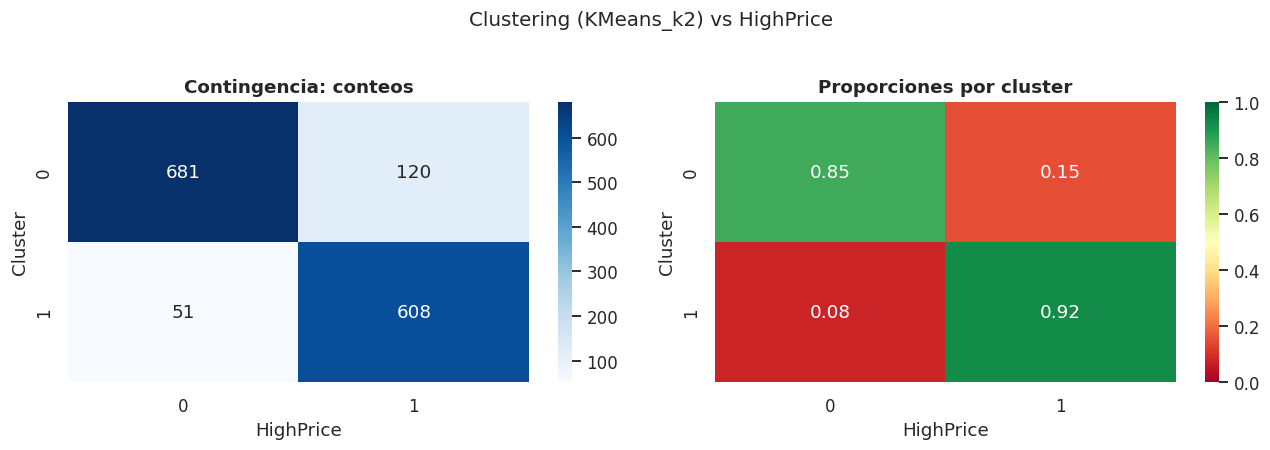


🔍 Interpretación:
  Cluster 0: 15.0% HighPrice=1 → predominantemente precio BAJO
  Cluster 1: 92.3% HighPrice=1 → predominantemente precio ALTO


In [ ]:
# Heatmap de diferenciación
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(ct_counts, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Contingencia: conteos', fontweight='bold')

sns.heatmap(ct_pct, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[1],
            vmin=0, vmax=1)
axes[1].set_title('Proporciones por cluster', fontweight='bold')

plt.suptitle(f'Clustering ({best_model_name}) vs HighPrice', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Interpretación automática
print('\n🔍 Interpretación:')
for cl in sorted(ct_pct.index):
    prop_alto = ct_pct.loc[cl, 1] if 1 in ct_pct.columns else 0
    etiq = 'precio ALTO' if prop_alto >= 0.6 else ('precio BAJO' if prop_alto <= 0.4 else 'mixto')
    print(f'  Cluster {cl}: {prop_alto:.1%} HighPrice=1 → predominantemente {etiq}')

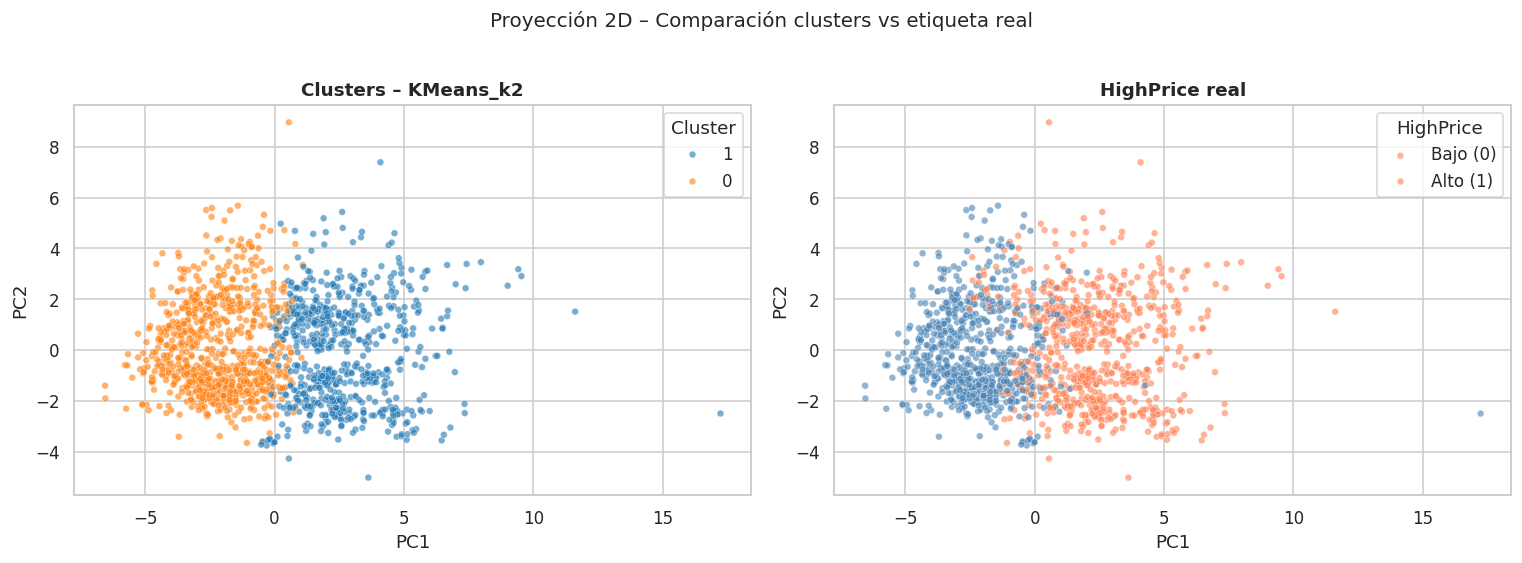

In [ ]:
# Visualización 2D de clusters y HighPrice
pca_2d = PCA(n_components=2, random_state=42)
X_vis  = pca_2d.fit_transform(X_processed)

vis_df = pd.DataFrame({
    'PC1':      X_vis[:, 0],
    'PC2':      X_vis[:, 1],
    'Cluster':  best_labels.astype(str),
    'HighPrice': y_ref.values.astype(str)
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Por cluster
sns.scatterplot(data=vis_df, x='PC1', y='PC2', hue='Cluster',
                palette='tab10', alpha=0.6, s=20, ax=axes[0])
axes[0].set_title(f'Clusters – {best_model_name}', fontweight='bold')

# Por HighPrice
sns.scatterplot(data=vis_df, x='PC1', y='PC2', hue='HighPrice',
                palette={"0": 'steelblue', "1": 'coral'}, alpha=0.6, s=20, ax=axes[1])
axes[1].set_title('HighPrice real', fontweight='bold')
axes[1].legend(title='HighPrice', labels=['Bajo (0)', 'Alto (1)'])

plt.suptitle('Proyección 2D – Comparación clusters vs etiqueta real', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Interpretación del análisis de diferenciación

**Comentario:**  
Si los clusters coinciden en gran medida con `HighPrice`, el algoritmo está aprendiendo una estructura
real de los datos sin usar la etiqueta.  
Un **ARI > 0.4** indica concordancia moderada-alta; un **ARI < 0.1** sugiere que los clusters
no capturan la variación de precio.

El gráfico de proporciones permite verificar cluster a cluster si hay dominancia de una clase,
lo que valida la utilidad del clustering como herramienta de segmentación de mercado inmobiliario.

In [ ]:
# Exportar tabla de resultados
results_all.to_csv('benchmark_clustering_houseprices.csv', index=False)
print('✅ Exportado: benchmark_clustering_houseprices.csv')

✅ Exportado: benchmark_clustering_houseprices.csv


---
## 🏁 Conclusión

En este trabajo se aplicaron los contenidos de la Unidad 3 sobre el dataset *House Prices*:

1. **Preparación de datos:** Se eliminaron columnas con más del 80% de valores nulos, se aplicó
   imputación por mediana para variables numéricas y por moda para categóricas, One Hot Encoding
   para variables nominales, y StandardScaler para normalizar la escala de las features.

2. **PCA vs sin PCA:** Se determinó el número mínimo de componentes que explican al menos el 90%
   de la varianza acumulada, reduciendo significativamente la dimensionalidad. Ambos escenarios
   fueron evaluados en paralelo.

3. **Benchmarking:** Se compararon 7 modelos distribuidos entre algoritmos de distancia
   (KMeans, Agglomerative, Birch) y de densidad (DBSCAN con eps optimizado por k-distancia, OPTICS).
   Esta comparación permite identificar ventajas y limitaciones de cada enfoque.

4. **Evaluación:** Se utilizaron métricas internas (Silhouette, Calinski-Harabasz, Davies-Bouldin)
   y externas (ARI, NMI respecto a `HighPrice`). El mejor modelo fue seleccionado priorizando
   la alineación con la variable real, validando si el clustering diferencia correctamente
   viviendas de precio alto y bajo.

5. **GitHub:** Los archivos fueron exportados y se incluyeron instrucciones para versionar
   el trabajo en un repositorio público.

> **Conclusión general:** El clustering no supervisado sobre House Prices logra capturar
> parcialmente la estructura de precios, confirmando que las features seleccionadas contienen
> información suficiente para diferenciar segmentos de mercado sin necesidad de la etiqueta.